<a href="https://colab.research.google.com/github/d2021101420/PCO213/blob/main/PCO213_Treinam01_MAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

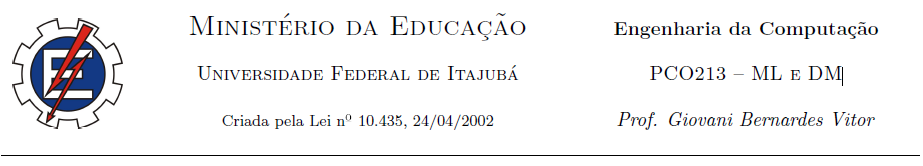

# Treinamento#1

Observações:
- Os códigos bem como as respostas textuais deverão ser enviados de maneira conjunta no arquivo com extensão .ipynb.
- Os demais arquivos, por exemplo, datasets podem ser enviados em formato compactado (.rar, .zip, etc.)
- Não serão aceitos o envio de arquivo no formato PDF ou DOC como resposta para o desenvolvimento das atividades.
- As atividades podem ser realizadas em grupos de no máximo 4 integrantes onde somente 1 deles será responsável pelo envio e postagem no SIGAA.
- Não serão aceitos a entrega das atividades fora do prazo e somente via SIGAA. Entregas via email não serão contabilizadas.


### Matrícula e nome completo: *2026102180 - MAURÍCIO ANDRÉ DE ALMEIDA*

In [133]:
#Carregue o arquivo dataset_treinamento01.zip e execute para descompactar

import zipfile
import os

zip_file_path = '/content/dataset_treinamento01.zip'
extract_dir = '/content/dataset'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Arquivo '{zip_file_path}' descompactado para '{extract_dir}'")
print(f"Conteúdo de '{extract_dir}':")
for item in os.listdir(extract_dir):
    print(item)
#Apaga o arquivo exemplo_cdigo_regresso.zip
os.remove(extract_dir+'/exemplo_cdigo_regresso.zip')

Arquivo '/content/dataset_treinamento01.zip' descompactado para '/content/dataset'
Conteúdo de '/content/dataset':
Q07_dataset_manutencao_preditiva_raw.csv
Q10_dataset_amostras_tempos.csv
Q05_dataset_corrente_temperatura.csv
exemplo_cdigo_regresso.zip


#1. Taxonomia do Aprendizado de Máquina
Considere os seguintes problemas de engenharia e classifique cada um como tarefa de classifição, regressão, clusterização ou redução de dimensionalidade. Justifique sua resposta indicando o tipo de output esperado e se trata de aprendizado supervisionado ou não supervisionado.
1. Prever a temperatura máxima de um transformador elétrico nas próximas 24 horas.
2. Identificar grupos de padrões de consumo de energia em clientes industriais sem rótulos.
3. Determinar se um disjuntor está em estado de falha ou operação normal.
4. Compactar um conjunto de 50 variáveis de processo em 5 componentes principais.

## Respostas - Taxonomia do Aprendizado de Máquina

1.  **Prever a temperatura máxima de um transformador elétrico nas próximas 24 horas.**
    *   **Classificação:** Regressão
    *   **Justificativa:** O objetivo é prever um valor contínuo (temperatura), que é uma característica da regressão. O modelo seria treinado com dados históricos de temperatura e outras variáveis (tempo, carga, ambiente) para aprender a relação e prever um valor numérico. É um problema de **aprendizado supervisionado**, pois há uma variável alvo (temperatura máxima) conhecida nos dados de treinamento.

2.  **Identificar grupos de padrões de consumo de energia em clientes industriais sem rótulos.**
    *   **Classificação:** Clusterização (Agrupamento)
    *   **Justificativa:** A tarefa envolve a descoberta de estruturas ou grupos inerentes nos dados sem nenhuma informação pré-existente sobre as categorias (sem rótulos). O output esperado são os agrupamentos de clientes com comportamentos de consumo similares. É um problema de **aprendizado não supervisionado**, pois não há uma variável alvo para supervisionar o treinamento.

3.  **Determinar se um disjuntor está em estado de falha ou operação normal.**
    *   **Classificação:** Classificação
    *   **Justificativa:** O objetivo é categorizar o disjuntor em uma de duas classes distintas e pré-definidas ('falha' ou 'operação normal'). O output esperado é uma etiqueta de classe. É um problema de **aprendizado supervisionado**, pois o modelo é treinado com exemplos de disjuntores em ambos os estados, onde a classe ('falha' ou 'normal') é a variável alvo conhecida.

4.  **Compactar um conjunto de 50 variáveis de processo em 5 componentes principais.**
    *   **Classificação:** Redução de Dimensionalidade
    *   **Justificativa:** O objetivo é transformar um conjunto de dados de alta dimensão (50 variáveis) em um conjunto de menor dimensão (5 componentes) enquanto preserva a maior parte da informação relevante. O output esperado são as 5 novas variáveis (componentes principais). É um problema de **aprendizado não supervisionado**, pois a redução não depende de uma variável alvo, mas sim da estrutura intrínseca dos dados.

#2. Underfitting, Overfitting e o Dilema Viés-Variância
Um engenheiro treina três modelos para prever a eficiência de um motor:
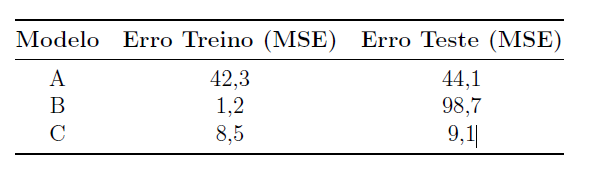



a. Identifique o fenômeno de generalização em cada modelo.

b. Para o modelo com *overfitting*, descreva três causas e duas estratégias de mitigação.

c. No dilema Viés-Variância, explique o “Sweet Spot” e sua relação com *Early Stopping*.


## Respostas - Underfitting, Overfitting e o Dilema Viés-Variância

**a. Identifique o fenômeno de generalização em cada modelo.**

*   **Modelo A (Erro Treino: 42,3, Erro Teste: 44,1):** Este modelo pode apresentar **Underfitting**, O erro de treino e o de teste estão muito próximos, o que indica que ele está conseguindo generalizar o (pouco) que aprendeu. O problema é que o erro é alto em ambos. Ele não conseguiu captar a lógica dos dados nem durante o treinamento. É como um aluno que não estudou nada: ele vai mal no simulado e mal na prova. Pode ser um indicativo de poucos dados de treinamento e teste, ou da necessidade de um modelos mais complexo.

*   **Modelo B (Erro Treino: 1,2, Erro Teste: 98,7):** Este modelo está sofrendo de **overfitting**. O erro de treino é extremamente baixo, sugerindo que o modelo memorizou os dados de treino, incluindo o ruído. No entanto, o erro de teste é muito alto, o que significa que o modelo falha em generalizar para novos dados. Ele se ajustou demais aos detalhes específicos do conjunto de treino e perdeu a capacidade de capturar os padrões subjacentes mais amplos.

*   **Modelo C (Erro Treino: 8,5, Erro Teste: 9,1):** Este modelo também apresenta **boa generalização**, similar ao Modelo A, mas com um desempenho superior (menor erro). O erro de treino e o erro de teste são baixos e próximos, indicando um bom equilíbrio entre ajuste aos dados de treino e capacidade de generalização.

**b. Para o modelo com overfitting (Modelo B), descreva três causas e duas estratégias de mitigação.**

**Causas do Overfitting:**

1.  **Configuração de Hiperparâmetros Extremas:**  a escolha inadequada de hiperparâmetros (profundidade máxima de uma árvore de decisão muito alta ou `n_neighbors` muito baixo para k-NN) pode levar o modelo a aprender demais os detalhes e o ruído dos dados de treino.
2.  **Dados de Treino Insuficientes:** Se o volume de dados de treino for pequeno ou não representativo da população geral, o modelo pode aprender o ruído e as particularidades desses poucos exemplos, em vez de padrões generalizáveis.
3.  **Características Irrelevantes ou Ruído nos Dados:** A presença de muitas características irrelevantes ou ruído nos dados de treino pode fazer com que o modelo tente aprender e se ajustar a esses elementos, diminuindo sua capacidade de generalização para dados mais limpos ou com características diferentes.

**Estratégias de Mitigação para Overfitting:**

1.  **Seleção ou Engenharia de Features:** Reduzir o número de features, remover características irrelevantes ou criar novas features mais informativas pode simplificar o espaço de problema e ajudar o modelo a focar nos padrões mais importantes, mitigando o overfitting.
2.  **Aumento de Dados (Data Augmentation):** Para casos de dados insuficientes, técnicas de aumento de dados podem ser aplicadas para gerar novas amostras de treino a partir das existentes. Isso expande o conjunto de treino, ajudando o modelo a aprender padrões mais robustos e a reduzir a memorização.

**c. No dilema Viés-Variância, explique o “Sweet Spot” e sua relação com *Early Stopping*.**

*   **O "Sweet Spot" no Dilema Viés-Variância:** Modelos mais simples tendem a ter um **alto viés**, pois não conseguem capturar a complexidade dos dados, levando a *underfitting* e **baixa variância** pois são consistentes em suas previsões, mas podem estar consistentemente errados. Modelos com maior capacidade de ajuste tendem a ter **baixo viés**, pois são capazes de se ajustar bem aos dados de treino e **alta variância**, pois são muito sensíveis a pequenas flutuações nos dados de treino, levando a *overfitting*. O "Sweet Spot" é o ponto ideal de complexidade do modelo onde há um equilíbrio entre viés e variância, resultando no menor erro de generalização possível. É o ponto onde o modelo é complexo o suficiente para aprender os padrões relevantes sem se ajustar ao ruído.

*   **Relação com *Early Stopping*:** *Early Stopping* é uma técnica usada durante o treinamento iterativo de modelos para encontrar esse "Sweet Spot". Durante o treinamento, o erro do modelo no conjunto de treino geralmente diminui continuamente, enquanto o erro em um **conjunto de validação** separado primeiro diminui e depois começa a aumentar quando o modelo começa a sofrer *overfitting*. *Early Stopping* monitora o desempenho do modelo no conjunto de validação e interrompe o treinamento assim que o erro de validação para de diminuir (ou começa a aumentar) por um certo número de épocas. Ao parar o treinamento antes que o *overfitting* se instale completamente, *Early Stopping* ajuda a capturar o modelo em seu "Sweet Spot", onde ele tem o melhor desempenho de generalização, evitando que ele se torne excessivamente complexo e com alta variância.

##3. Tratamento de Dados Ausentes

Dado o dataset abaixo:

```
data = {
  'temperatura ': [85.2 , np.nan , 90.1 , 88.7 , np.nan , 92.3 , 87.5 , np.nan , 89.0 , 91.4] ,
  'pressao ': [1.2 , 1.5 , np.nan , 1.3 , 1.4 , np.nan , 1.1 , 1.6 , 1.3 , np.nan ] ,
  'vibracao ': [0.05 , 0.07 , 0.06 , np.nan , 0.08 , 0.05 , np.nan , 0.09 , 0.06 , 0.07] ,
  'status ': ['normal ','falha ','normal ','normal ', np.nan ,' normal ','falha ','normal ','normal ','falha ']
}
```


a. Calcule o percentual de ausência por coluna.

b. Aplique imputação por mediana (numéricos) e moda (categórico).

c. Use KNNImputer(n_neighbors=3) e compare com a mediana via RMSE.

## 3. Tratamento de Dados Ausentes


In [134]:
import pandas as pd
import numpy as np

data = {
  'temperatura': [85.2, np.nan, 90.1, 88.7, np.nan, 92.3, 87.5, np.nan, 89.0, 91.4],
  'pressao': [1.2, 1.5, np.nan, 1.3, 1.4, np.nan, 1.1, 1.6, 1.3, np.nan],
  'vibracao': [0.05, 0.07, 0.06, np.nan, 0.08, 0.05, np.nan, 0.09, 0.06, 0.07],
  'status': ['normal', 'falha', 'normal', 'normal', np.nan, 'normal', 'falha', 'normal', 'normal', 'falha']
}

df = pd.DataFrame(data)
print("DataFrame Original:")
print(df)

DataFrame Original:
   temperatura  pressao  vibracao  status
0         85.2      1.2      0.05  normal
1          NaN      1.5      0.07   falha
2         90.1      NaN      0.06  normal
3         88.7      1.3       NaN  normal
4          NaN      1.4      0.08     NaN
5         92.3      NaN      0.05  normal
6         87.5      1.1       NaN   falha
7          NaN      1.6      0.09  normal
8         89.0      1.3      0.06  normal
9         91.4      NaN      0.07   falha


In [135]:
percentual_ausencia = df.isnull().sum() / len(df) * 100
print("a. Percentual de ausência por coluna:\n")
print(percentual_ausencia)

a. Percentual de ausência por coluna:

temperatura    30.0
pressao        30.0
vibracao       20.0
status         10.0
dtype: float64


In [136]:
# b. Aplique imputação por mediana (numéricos) e moda (categórico):

df_new = df.copy()
num_cols = ['temperatura', 'pressao', 'vibracao']
cat_cols = ['status']

# colunas numéricas (mediana)
for col in num_cols:
    median_val = df[col].median()
    new_col = col+'_mediana'
    df_new[new_col] = df_new[col].fillna(median_val)

# colunas categóricas (moda)
for col in cat_cols:
    mode_val = df[col].mode()[0]
    new_col = col+'_moda'
    df_new[new_col] = df_new[col].fillna(mode_val)

print("b. DataFrame após imputação por Mediana (numéricos) e Moda (categóricos):")
print(df_new)

b. DataFrame após imputação por Mediana (numéricos) e Moda (categóricos):
   temperatura  pressao  vibracao  status  temperatura_mediana  \
0         85.2      1.2      0.05  normal                 85.2   
1          NaN      1.5      0.07   falha                 89.0   
2         90.1      NaN      0.06  normal                 90.1   
3         88.7      1.3       NaN  normal                 88.7   
4          NaN      1.4      0.08     NaN                 89.0   
5         92.3      NaN      0.05  normal                 92.3   
6         87.5      1.1       NaN   falha                 87.5   
7          NaN      1.6      0.09  normal                 89.0   
8         89.0      1.3      0.06  normal                 89.0   
9         91.4      NaN      0.07   falha                 91.4   

   pressao_mediana  vibracao_mediana status_moda  
0              1.2             0.050      normal  
1              1.5             0.070       falha  
2              1.3             0.060      norm

In [137]:
#c. Use KNNImputer(n_neighbors=3) e compare com a mediana via RMSE.

from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error

print('c. Use KNNImputer(n_neighbors=3) ')
# Copiar o dataset original
df_imp = df.copy()
# Eliminar coluna não numérica
df_imp = df_imp.drop(columns=['status'])

print("\nDataFrame Numérico Original:\n")
print(df_imp)

# Renomear colunas
knn_cols = [col + '_knn' for col in num_cols]
#print(knn_cols)

# Imputação com KNNImputer
k_imputer = KNNImputer(n_neighbors=3)
df_imp = pd.DataFrame(k_imputer.fit_transform(df_imp),
                                        columns=knn_cols)

print("\nDataFrame Numérico após imputação com KNNImputer:\n")
print(df_imp)


c. Use KNNImputer(n_neighbors=3) 

DataFrame Numérico Original:

   temperatura  pressao  vibracao
0         85.2      1.2      0.05
1          NaN      1.5      0.07
2         90.1      NaN      0.06
3         88.7      1.3       NaN
4          NaN      1.4      0.08
5         92.3      NaN      0.05
6         87.5      1.1       NaN
7          NaN      1.6      0.09
8         89.0      1.3      0.06
9         91.4      NaN      0.07

DataFrame Numérico após imputação com KNNImputer:

   temperatura_knn  pressao_knn  vibracao_knn
0        85.200000          1.2          0.05
1        91.266667          1.5          0.07
2        90.100000          1.5          0.06
3        88.700000          1.3          0.07
4        91.266667          1.4          0.08
5        92.300000          1.5          0.05
6        87.500000          1.1          0.08
7        91.266667          1.6          0.09
8        89.000000          1.3          0.06
9        91.400000          1.5          0.07


In [138]:
# União dos dfs
df_new = pd.concat([df_new, df_imp], axis = 1)
df_new = df_new.iloc[:, [3,7,0,4,8,1,5,9,2,6,10 ]]
print(df_new)

   status status_moda  temperatura  temperatura_mediana  temperatura_knn  \
0  normal      normal         85.2                 85.2        85.200000   
1   falha       falha          NaN                 89.0        91.266667   
2  normal      normal         90.1                 90.1        90.100000   
3  normal      normal         88.7                 88.7        88.700000   
4     NaN      normal          NaN                 89.0        91.266667   
5  normal      normal         92.3                 92.3        92.300000   
6   falha       falha         87.5                 87.5        87.500000   
7  normal      normal          NaN                 89.0        91.266667   
8  normal      normal         89.0                 89.0        89.000000   
9   falha       falha         91.4                 91.4        91.400000   

   pressao  pressao_mediana  pressao_knn  vibracao  vibracao_mediana  \
0      1.2              1.2          1.2      0.05             0.050   
1      1.5         

In [139]:
#c. Use KNNImputer(n_neighbors=3) e compare com a mediana via RMSE.
from sklearn.metrics import mean_squared_error

for col in num_cols:
  print(f"\nComparação da mediana com o KNN para a coluna: {col}")
  real_val = df_new[col + '_mediana']
  pred_val = df_new[col + '_knn']
  rmse = np.sqrt(mean_squared_error(real_val, pred_val))
  print(f"RMSE ({col}_mediana vs {col}_knn): {rmse:.4f}")



Comparação da mediana com o KNN para a coluna: temperatura
RMSE (temperatura_mediana vs temperatura_knn): 1.2415

Comparação da mediana com o KNN para a coluna: pressao
RMSE (pressao_mediana vs pressao_knn): 0.1095

Comparação da mediana com o KNN para a coluna: vibracao
RMSE (vibracao_mediana vs vibracao_knn): 0.0050


##4. Tipos de Dados e Codificação
Classifique os atributos abaixo quanto ao nível de mensuração (nominal, ordinal, discreta, contínua) e indique a codificação (*Label, One-Hot* ou *Dummy*):

- Nível de criticidade (Baixo a Crítico); Tipo de equipamento; Tensão de operação (kV); Número de falhas; Região de instalação.

- Explique a "Armadilha da Variável Dummy" e a multicolinearidade.

### RESPOSTAS: Classificação dos Atributos:

*   **Nível de criticidade (Baixo a Crítico)**:
    *   **Nível de Mensuração:** Ordinal = Existe uma ordem entre as categorias (Baixo < Médio < Alto < Crítico).
    *   **Codificação:** Label Encoding. Como há uma ordem, podemos atribuir valores numéricos crescentes (ex: Baixo=1, Médio=2, Alto=3, Crítico=4).

*   **Tipo de equipamento (Transformador, Disjuntor, Relé)**:
    *   **Nível de Mensuração:** Nominal = As categorias representam tipos distintos sem uma ordem específica.
    *   **Codificação:** One-Hot Encoding ou Dummy Encoding. Para evitar que o modelo interprete uma ordem inexistente e para representar cada categoria de forma independente.

*   **Tensão de operação (kV)**:
    *   **Nível de Mensuração:** Contínua = Pode assumir qualquer valor dentro de um intervalo.
    *   **Codificação:** Não requer codificação

*   **Número de falhas**:
    *   **Nível de Mensuração:** Discreta = Representa contagens em valores inteiros.
    *   **Codificação:** Não requer codificação.

*   **Região de instalação**:
    *   **Nível de Mensuração:** Nominal = As categorias representam tipos distintos sem uma ordem específica.
    *   **Codificação:** One-Hot Encoding ou Dummy Encoding. Para representar cada região como uma variável independente.


### Explicação da "Armadilha da Variável Dummy" e Multicolinearidade:

A **Armadilha da Variável Dummy (Dummy Variable Trap)** ocorre quando usamos o One-Hot Encoding para converter variáveis categóricas em variáveis numéricas binárias e incluímos todas as categorias como variáveis no modelo de regressão. Isso leva à **multicolinearidade perfeita**.

*   **Multicolinearidade** é quando uma variável está diretamente relacionada com outra ou outras variáveis, e pode ser prevista a partir destas. Isso pode dificultar o isolamento da contribuição individual e causar instabilidade no modelo.

*   **Como a Armadilha da Variável Dummy causa Multicolinearidade Perfeita:** Se uma variável categórica tem *k* categorias e criamos *k* novas colunas binárias (dummies), a soma dessas *k* colunas será sempre 1 (assumindo que cada observação pertence a exatamente uma categoria). Por exemplo, se tivermos 'Região' com categorias 'Norte', 'Sul', 'Leste', e 'Oeste', e criarmos 4 variáveis dummy `Regiao_Norte`, `Regiao_Sul`, `Regiao_Leste`, `Regiao_Oeste`, então `Regiao_Norte + Regiao_Sul + Regiao_Leste + Regiao_Oeste = 1`. Isso significa que uma das variáveis dummy pode ser perfeitamente prevista pelas outras *k-1* variáveis, resultando em multicolinearidade perfeita.

*   **Solução:** Para evitar a Armadilha da Variável Dummy, geralmente removemos uma das *k* variáveis dummy. Isso é conhecido como **Dummy Encoding**. A categoria removida torna-se a categoria de referência, e os coeficientes das demais variáveis dummy são interpretados em relação a essa categoria base. Por exemplo, se removermos `Regiao_Norte`, ela será representada quando o coeficiente de todas as outras regiões for igual a zero.

##5. Normalização: MinMaxScaler vs StandardScaler

a. Aplique ambos os scalers nos vetores **corrente** e **temperatura** fornecidos.

b. Plote histogramas e comente sobre a preservação da topologia.

c. Qual técnica é mais sensível a *outliers*? Justifique matematicamente.

## RESPOSTAS: Normalização: MinMaxScaler vs StandardScaler

In [140]:
# Carregar o df
df_corr_temp = pd.read_csv('/content/dataset/Q05_dataset_corrente_temperatura.csv')
print(df_corr_temp)

        corrente  temperatura
0     148.247018    48.029596
1      88.231927    57.529315
2     162.516386    50.095459
3     245.249411    68.122208
4      79.168956    95.800625
...          ...          ...
9995  283.573172   161.544871
9996  -87.573895   100.389787
9997   34.636877    74.946198
9998  148.157363   108.951438
9999  162.204478    24.052689

[10000 rows x 2 columns]


In [141]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
print('a. Aplique ambos os scalers nos vetores corrente e temperatura fornecidos.\n')
df_scaled_minmax = pd.DataFrame(MinMaxScaler().fit_transform(df_corr_temp), columns=['corrente','temperatura'])

df_scaled_standard = pd.DataFrame(StandardScaler().fit_transform(df_corr_temp), columns=['corrente','temperatura'])

print("\nDataFrame após MinMaxScaler para colunas selecionadas:")
print(df_scaled_minmax)

print("\nDataFrame após StandardScaler para colunas selecionadas:")
print(df_scaled_standard)

a. Aplique ambos os scalers nos vetores corrente e temperatura fornecidos.


DataFrame após MinMaxScaler para colunas selecionadas:
      corrente  temperatura
0     0.563042     0.381248
1     0.482139     0.425996
2     0.582278     0.390980
3     0.693806     0.475894
4     0.469922     0.606272
...        ...          ...
9995  0.745468     0.915957
9996  0.245145     0.627889
9997  0.409891     0.508038
9998  0.562921     0.668218
9999  0.581857     0.268306

[10000 rows x 2 columns]

DataFrame após StandardScaler para colunas selecionadas:
      corrente  temperatura
0     0.470979    -0.690676
1    -0.151817    -0.335246
2     0.619057    -0.613382
3     1.477603     0.061085
4    -0.245866     1.096667
...        ...          ...
9995  1.875301     3.556473
9996 -1.976209     1.268369
9997 -0.707989     0.316403
9998  0.470049     1.588701
9999  0.615820    -1.587767

[10000 rows x 2 columns]


b. Plote histogramas e comente sobre a preservação da topologia.


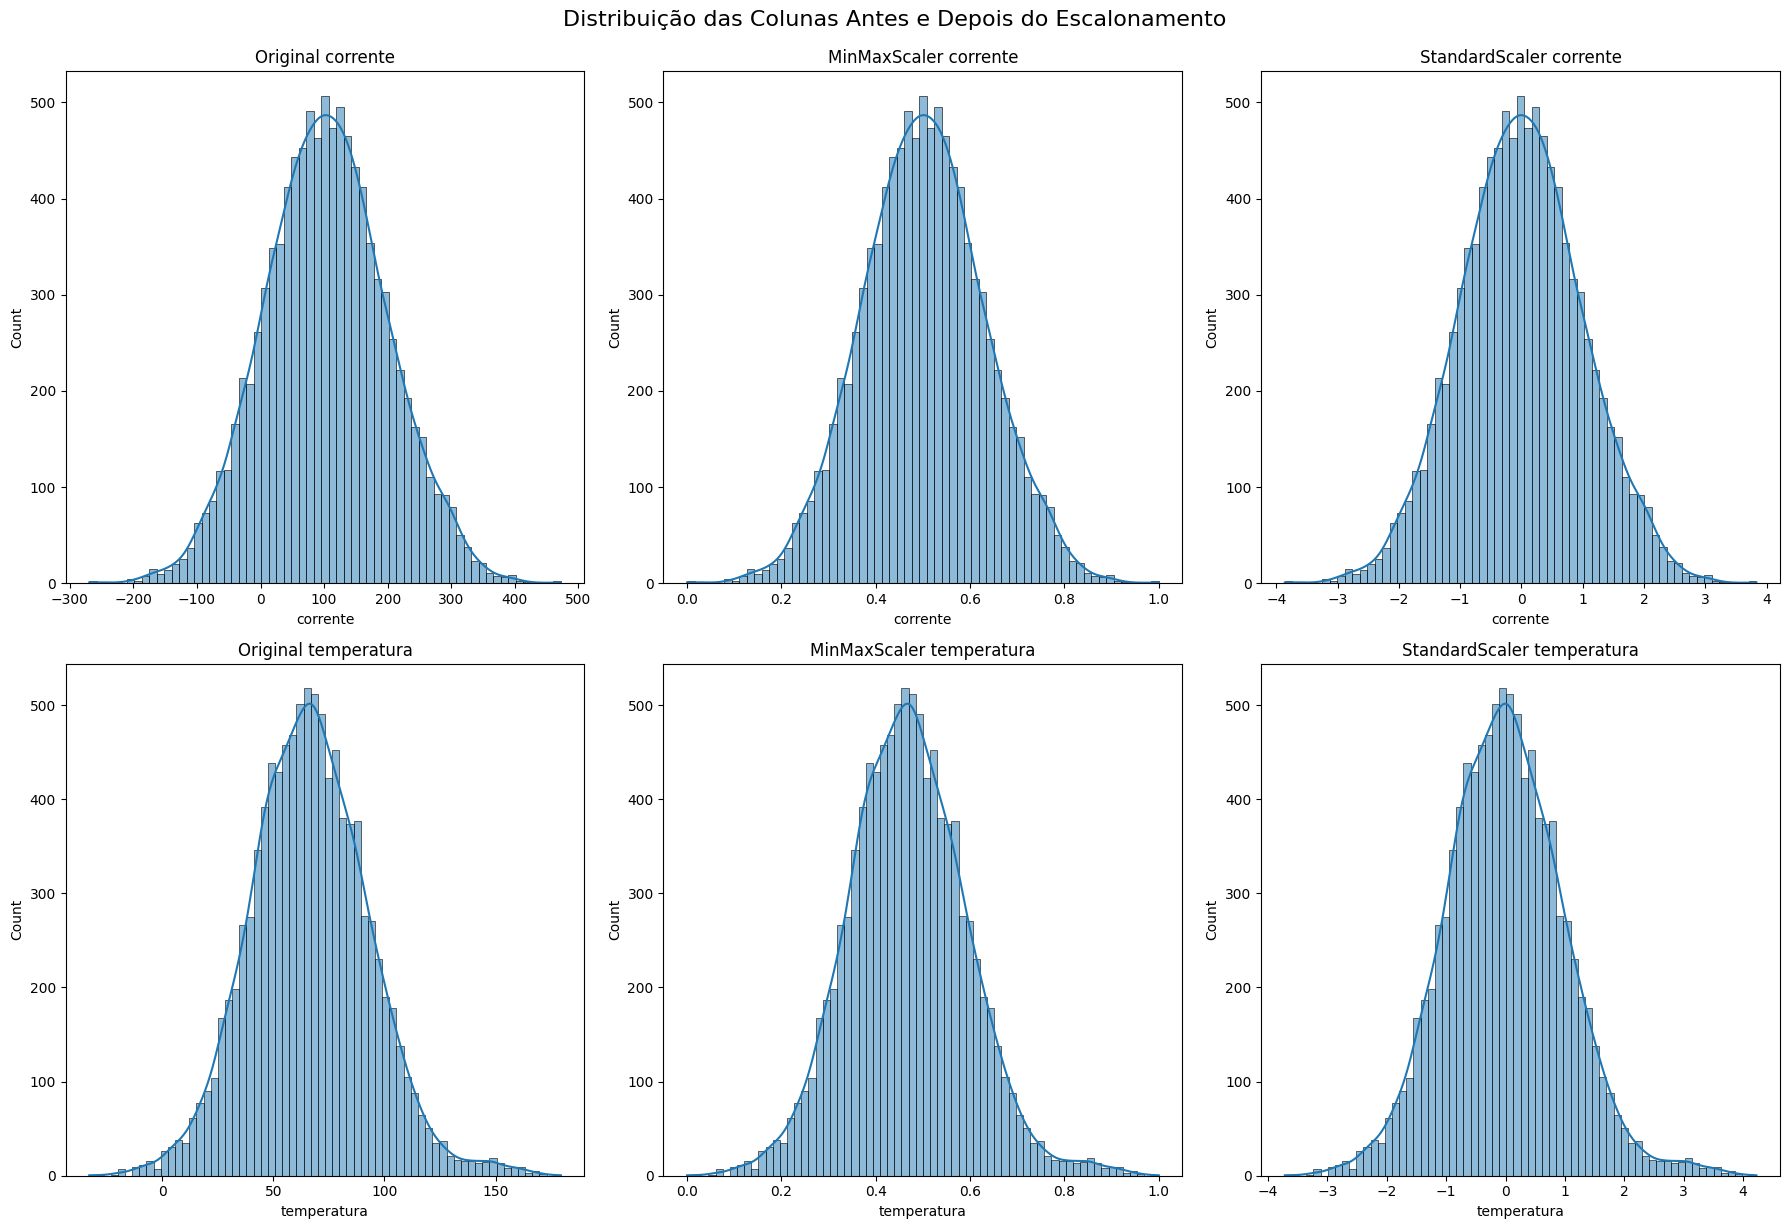

In [142]:
print('b. Plote histogramas e comente sobre a preservação da topologia.')


plt.figure(figsize=(18, 12))
for i, col in enumerate(df_corr_temp.columns):
    plt.subplot(2, 3, i*3 + 1)
    sns.histplot(df_corr_temp[col], kde=True)
    plt.title(f'Original {col}')
    plt.subplot(2, 3, i*3 + 2)
    sns.histplot(df_scaled_minmax[col], kde=True)
    plt.title(f'MinMaxScaler {col}')
    plt.subplot(2, 3, i*3 + 3)
    sns.histplot(df_scaled_standard[col], kde=True)
    plt.title(f'StandardScaler {col}')

plt.tight_layout()
plt.suptitle('Distribuição das Colunas Antes e Depois do Escalonamento', y=1.02, fontsize=16)
plt.show()

b. Comentário sobre a preservação da topologia nos histogramas: Conforme observado nos histogramas, tanto o MinMaxScaler quanto o StandardScaler preservam a forma (topologia) da distribuição original dos dados. Eles são transformações lineares que apenas alteram a escala e a localização dos dados, mas não modificam a estrutura subjacente, o skewness ou a curtose da distribuição. Ou seja, se a distribuição original era assimétrica ou tinha múltiplos picos, ela continuará com essas características após o escalonamento com qualquer um desses métodos.

c. Qual técnica é mais sensível a outliers? Justifique matematicamente.

O MinMaxScaler é mais sensível a outliers do que o StandardScaler.

Justificativa Matemática:

**MinMaxScaler**: A fórmula do MinMaxScaler é: $$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Nesta fórmula, o escalonamento é diretamente dependente dos valores mínimo ($X_{min}$) e máximo ($X_{max}$) do conjunto de dados. Se houver um outlier, ele puxará o $X_{max}$ ou $X_{min}$ para um valor muito distante, comprimindo os outros pontos em um intervalo muito pequeno. O MinMaxScaler força todos os dados a caberem dentro de um intervalo fixo (geralmente [0, 1] ou [-1, 1]), e um valor extremo altera a amplitude dos os outros pontos.



**StandardScaler**: A fórmula do StandardScaler é: $$X_{scaled} = \frac{X - \mu}{\sigma}$$$$X_{scaled} = \frac{X - \mu}{\sigma}$$

Onde $\mu$ é a média e $\sigma$ é o desvio padrão do conjunto de dados. Embora a média e o desvio padrão também sejam afetados por outliers, eles tem um impacto menor.  Isso ocorre porque o desvio padrão é calculado com base na distância de cada ponto em relação à média, e não apenas nos valores máximo e mínimo. Portanto, o StandardScaler tende a ser menos sensível a outliers, embora ainda seja afetado por eles, pois a média e o desvio padrão são baseados em todos os pontos de dados.

Em resumo, como o MinMaxScaler depende diretamente dos valores máximo e mínimo, que são extremamente suscetíveis a outliers, ele é muito mais sensível a eles do que o StandardScaler, que usa a média e o desvio padrão.

##6. Outliers com Método IQR

Valores de corrente pico: [112, 118, ..., 450, ..., 3, ...].

a. Calcule manualmente Q1, Q3, IQR e limites. Identifique os *outliers*.

b. Implemente em Python e gere um *boxplot*.

c. Compare as estratégias de remoção e transformação logarítmica.

### RESPOSTAS

In [143]:
print('a. Calcule manualmente Q1, Q3, IQR e limites. Identifique os outliers:\n')

import pandas as pd
import numpy as np

df_corr_temp = pd.read_csv('/content/dataset/Q05_dataset_corrente_temperatura.csv')

df_corrente = df_corr_temp['corrente']

# Calcular Q1, Q3 e IQR
Q1 = df_corrente.quantile(0.25)
Q3 = df_corrente.quantile(0.75)
IQR = Q3 - Q1

# Calcular os limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df_corrente[(df_corrente < lower_bound) | (df_corrente > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Inferior: {lower_bound:.2f}")
print(f"Limite Superior: {upper_bound:.2f}")
print(f"\nNúmero de Outliers identificados: {len(outliers)}")
print("Valores dos Outliers:")
print(outliers)


a. Calcule manualmente Q1, Q3, IQR e limites. Identifique os outliers:

Q1: 38.57
Q3: 166.26
IQR: 127.69
Limite Inferior: -152.97
Limite Superior: 357.80

Número de Outliers identificados: 77
Valores dos Outliers:
179     358.397225
209     465.441535
262    -205.048903
478     392.300914
646    -153.596674
           ...    
8726    399.757259
9258    362.953276
9573   -158.172428
9606   -163.523122
9770   -269.426289
Name: corrente, Length: 77, dtype: float64


b. Implemente em Python e gere um boxplot:



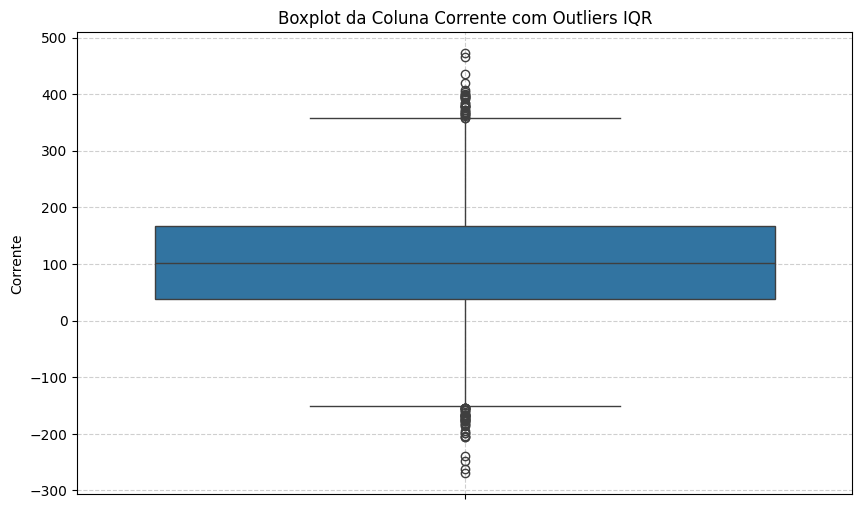

In [144]:
print('b. Implemente em Python e gere um boxplot:\n')

import matplotlib.pyplot as plt
import seaborn as sns

# Gerar o boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_corrente)
plt.title('Boxplot da Coluna Corrente com Outliers IQR')
plt.ylabel('Corrente')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### c. Compare as estratégias de remoção e transformação logarítmica.

**1. Remoção de Outliers:**

*   **Descrição:** Consiste em simplesmente remover os valores identificados como *outliers*.
*   **Prós:**
    *   Simplifica o dataset e a análise.
    *   Pode melhorar significativamente o desempenho de modelos sensíveis a *outliers* (como regressão linear, modelos baseados em distância).
*   **Contras:**
    *   **Perda de Informação:** Se a quantidade de *outliers* for grande, remover essas observações pode levar a uma perda considerável de dados valiosos, prejudicando a capacidade de generalização do modelo.
    *   **Enviesamento:** Os *outliers* podem, na verdade, conter informações importantes sobre variações incomuns, mas legítimas, no processo. Removê-los pode introduzir um viés no modelo.
    *   **Não recomendado para *outliers* legítimos:** Se o *outlier* representa um evento real e raro que é relevante para o problema, removê-lo seria um erro.

**2. Transformação Logarítmica:**

*   **Descrição:** Aplica uma função logarítmica aos dados. Essa transformação é eficaz para distribuições com assimetria positiva (cauda longa à direita).
*   **Prós:**
    *   **Reduz o Impacto de Outliers:** Valores extremos são "comprimidos" pela função logarítmica, tornando a distribuição mais simétrica e reduzindo a influência dos *outliers*.
    *   **Preserva Informação:** Ao contrário da remoção, a transformação mantém todas as observações no dataset, preservando a informação que os *outliers* podem conter.
    *   **Normaliza Distribuições:** Pode ajudar a aproximar a distribuição dos dados de uma distribuição normal, o que é benéfico para alguns modelos estatísticos que assumem normalidade.
*   **Contras:**
    *   **Interpretabilidade:** Os valores transformados não são mais diretamente interpretáveis na escala original, o que pode dificultar a comunicação dos resultados.
    *   **Não universal:** Funciona melhor para *outliers* na cauda superior e dados não negativos. Não é apropriada para *outliers* na cauda inferior ou dados que incluem zero ou valores negativos.

**Comparação e Escolha:**

*   A **remoção** é uma medida drástica que deve ser usada com cautela, principalmente quando se tem certeza de que os *outliers* são erros de medição ou anomalias que não representam o fenômeno em estudo.
*   A **transformação logarítmica** é geralmente uma abordagem mais suave, pois mantém todos os dados. É preferível quando os *outliers* são valores válidos, mas extremos, e o objetivo é reduzir sua influência sem descartar as observações. É particularmente útil para modelos que esperam dados mais próximos de uma distribuição normal ou com variância mais estável.


##7. Pipeline de Codificação Categórica

Utilize o dataset de inspeção (*Transformador, Disjuntor, Relé*).

a. Aplique **LabelEncoder** em criticidade e corrija a ordem se necessário.

b. Aplique **get dummies(drop first=True)**. O que a categoria eliminada representa?

### RESPOSTAS:

In [145]:
print('Leitura do dataset de inspeção:\n')


df_man_pred = pd.read_csv('/content/dataset/Q07_dataset_manutencao_preditiva_raw.csv')
print(df_man_pred)

Leitura do dataset de inspeção:

     criticidade         equipamento  regiao  horas_operacao  temperatura_op  \
0           Alto                Relé   Oeste           12063            62.6   
1          Médio              Reator  Centro           10404            62.7   
2           Alto       Transformador   Oeste           10479            71.9   
3           Alto  Chave Seccionadora   Leste            8507            62.1   
4          Baixo              Reator   Leste            1337            41.6   
...          ...                 ...     ...             ...             ...   
1995        Alto           Disjuntor   Leste            9863            61.6   
1996       Baixo              Reator   Oeste            8237            57.8   
1997       Baixo           Capacitor     Sul            7419            48.1   
1998        Alto              Reator   Norte           15884            76.4   
1999       Médio       Transformador   Norte            7494            54.0   

      

In [146]:
from sklearn.preprocessing import LabelEncoder

print('a. Aplique LabelEncoder em criticidade (sem ordem pré-definida):')

df_processed = df_man_pred.copy()

df_processed['criticidade_encoded'] = LabelEncoder().fit_transform(df_processed['criticidade'])

print("DataFrame com 'criticidade' codificada:")
print(df_processed[['criticidade', 'criticidade_encoded']])
print("\nValores únicos e sua codificação:")
print(df_processed[['criticidade', 'criticidade_encoded']].drop_duplicates().sort_values('criticidade_encoded'))

a. Aplique LabelEncoder em criticidade (sem ordem pré-definida):
DataFrame com 'criticidade' codificada:
     criticidade  criticidade_encoded
0           Alto                    0
1          Médio                    3
2           Alto                    0
3           Alto                    0
4          Baixo                    1
...          ...                  ...
1995        Alto                    0
1996       Baixo                    1
1997       Baixo                    1
1998        Alto                    0
1999       Médio                    3

[2000 rows x 2 columns]

Valores únicos e sua codificação:
  criticidade  criticidade_encoded
0        Alto                    0
4       Baixo                    1
5     Crítico                    2
1       Médio                    3


In [147]:
# Define a ordem das categorias para garantir a codificação correta
criticidade_order = ['Baixo', 'Médio', 'Alto', 'Crítico']
df_processed['criticidade'] = pd.Categorical(df_processed['criticidade'], categories=criticidade_order, ordered=True)

# Atribui os códigos numéricos com base na ordem definida da categoria
df_processed['criticidade_encoded'] = df_processed['criticidade'].cat.codes

print("DataFrame com 'criticidade' codificada (ordem definida):")
print(df_processed[['criticidade', 'criticidade_encoded']])
print("\nValores únicos e sua codificação:")
print(df_processed[['criticidade', 'criticidade_encoded']].drop_duplicates().sort_values('criticidade_encoded'))

DataFrame com 'criticidade' codificada (ordem definida):
     criticidade  criticidade_encoded
0           Alto                    2
1          Médio                    1
2           Alto                    2
3           Alto                    2
4          Baixo                    0
...          ...                  ...
1995        Alto                    2
1996       Baixo                    0
1997       Baixo                    0
1998        Alto                    2
1999       Médio                    1

[2000 rows x 2 columns]

Valores únicos e sua codificação:
  criticidade  criticidade_encoded
4       Baixo                    0
1       Médio                    1
0        Alto                    2
5     Crítico                    3


In [148]:
print('b. Aplique `get_dummies(drop_first=True)`. O que a categoria eliminada representa?\n')

print("\nCategorias originais da coluna 'equipamento':")
print(df_man_pred['equipamento'].unique())

df_processed = pd.get_dummies(df_processed, columns=['equipamento'], drop_first=True)

print("\nDataFrame com 'equipamento' codificado via One-Hot Encoding (drop_first=True):")
print(df_processed)


b. Aplique `get_dummies(drop_first=True)`. O que a categoria eliminada representa?


Categorias originais da coluna 'equipamento':
['Relé' 'Reator' 'Transformador' 'Chave Seccionadora' 'Capacitor' 'TC/TP'
 'Disjuntor' 'Para-raios']

DataFrame com 'equipamento' codificado via One-Hot Encoding (drop_first=True):
     criticidade  regiao  horas_operacao  temperatura_op  num_manutencoes  \
0           Alto   Oeste           12063            62.6                9   
1          Médio  Centro           10404            62.7                6   
2           Alto   Oeste           10479            71.9                0   
3           Alto   Leste            8507            62.1                5   
4          Baixo   Leste            1337            41.6                3   
...          ...     ...             ...             ...              ...   
1995        Alto   Leste            9863            61.6                8   
1996       Baixo   Oeste            8237            57.8                

**Explicação da categoria eliminada (`drop_first=True`):**

Quando usamos `drop_first=True` no `pd.get_dummies`, uma das categorias da variável original é eliminada para evitar a **Armadilha da Variável Dummy (Dummy Variable Trap)** e a multicolinearidade. A categoria eliminada se torna a **categoria de referência**.

Neste caso, a categoria 'equipamento' foi transformada em múltiplas colunas binárias. A categoria que foi eliminada é a do equipamento Capacitor (que viria primeiro em ordem alfabética). Se observarmos as colunas criadas (`equipamento_Disjuntor`, `equipamento_Relé`, `equipamento_Reator`, etc.), a categoria que não existe (`equipamento_Capacitor`) é a que serve de base, e será representada quando o valor de todas as outras são 0 (zero).


##8. Estratégias de Divisão: Holdout vs K-Fold

Compare *Holdout* (80/20), *K-Fold* (K=5, 10) e *Stratified K-Fold*.

- Reporte média, desvio padrão e custo computacional em uma tabela.

### RESPOSTAS:

In [149]:
# Preparação dos dados
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# One-Hot Encoding com drop_first=True para 'regiao' (variável nominal)
df_processed = pd.get_dummies(df_processed, columns=['regiao'], drop_first=True)

# Remover a coluna original 'criticidade' para evitar redundância com 'criticidade_encoded'
df_processed = df_processed.drop(columns=['criticidade'])

# Definir X e y
X = df_processed.drop(columns=['falha'])
y = df_processed['falha']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Primeiras 5 linhas do DataFrame processado (features):")
display(X.head())
print("Primeiras 5 linhas do Target (falha):")
display(y.head())

Features (X) shape: (2000, 16)
Target (y) shape: (2000,)
Primeiras 5 linhas do DataFrame processado (features):


,horas_operacao,temperatura_op,num_manutencoes,idade_anos,criticidade_encoded,equipamento_Chave Seccionadora,equipamento_Disjuntor,equipamento_Para-raios,equipamento_Reator,equipamento_Relé,equipamento_TC/TP,equipamento_Transformador,regiao_Leste,regiao_Norte,regiao_Oeste,regiao_Sul
0,12063,62.6,9,20.2,2,False,False,False,False,True,False,False,False,False,True,False
1,10404,62.7,6,3.6,1,False,False,False,True,False,False,False,False,False,False,False
2,10479,71.9,0,4.9,2,False,False,False,False,False,False,True,False,False,True,False
3,8507,62.1,5,19.2,2,True,False,False,False,False,False,False,True,False,False,False
4,1337,41.6,3,26.1,0,False,False,False,True,False,False,False,True,False,False,False


Primeiras 5 linhas do Target (falha):


,falha
0,0
1,0
2,0
3,0
4,0


**Comparação das Estratégias de Divisão**
Agora que os dados estão preparados, vamos implementar e comparar as diferentes estratégias de divisão:

1.  **Holdout (80/20)**
2.  **K-Fold (K=5)**
3.  **K-Fold (K=10)**
4.  **Stratified K-Fold (K=5)**

Para cada estratégia, treinaremos um modelo de Regressão Logística e avaliaremos a acurácia, seu desvio padrão e o tempo de execução.

In [150]:
results = []

# --- 1. Holdout (80/20) ---
start_time = time.time()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
end_time = time.time()
results.append({
    'Estratégia': 'Holdout (80/20)',
    'Acurácia Média': f'{accuracy:.4f}',
    'Desvio Padrão da Acurácia': 'N/A',
    'Tempo Computacional (s)': f'{(end_time - start_time):.4f}'
})



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [151]:
# Para evitar os ConvergenceWarning no modelo LogisticRegression, precisamos aplicar um passo
# adicional de transformação nos dados, vamos usar StandardScaler para aplicar a mesma escala
# em todos os dados

from sklearn.preprocessing import StandardScaler

# As colunas criadas por get_dummies não precisam ser escalonadas com StandardScaler já que
# são binárias
# Vou Filtrar apenas as colunas numéricas que não são one-hot encoded ou já transformadas
# As colunas numéricas originais são 'horas_operacao', 'temperatura_op', 'num_manutencoes',
# 'idade_anos'.
# 'criticidade_encoded' é numérica e também se beneficia de escalonamento.

numerical_cols_to_scale = ['horas_operacao', 'temperatura_op', 'num_manutencoes', 'idade_anos', 'criticidade_encoded']

X_scaled = X.copy()
X_scaled[numerical_cols_to_scale] = StandardScaler().fit_transform(X_scaled[numerical_cols_to_scale])

print("Dados numéricos escalonados com StandardScaler:\n")
print(X_scaled)

Dados numéricos escalonados com StandardScaler:

      horas_operacao  temperatura_op  num_manutencoes  idade_anos  \
0           0.826171        0.124043         1.585961    0.583828   
1           0.441450        0.131694         0.549611   -1.376219   
2           0.458843        0.835550        -1.523089   -1.222721   
3           0.001538        0.085790         0.204161    0.465753   
4          -1.661179       -1.482586        -0.486739    1.280472   
...              ...             ...              ...         ...   
1995        0.315993        0.047537         1.240511    0.926246   
1996       -0.061075       -0.243186         0.895061    0.442138   
1997       -0.250769       -0.985296        -1.177639   -1.210914   
1998        1.712257        1.179828        -1.177639   -1.482487   
1999       -0.233376       -0.533910        -0.141289    0.394908   

      criticidade_encoded  equipamento_Chave Seccionadora  \
0                0.831133                           False   


In [152]:
results = []

# --- 1. Holdout (80/20) ---
start_time = time.time()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)
model = LogisticRegression(max_iter=5000, random_state=42) # Aumentar max_iter para garantir convergência
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
end_time = time.time()
results.append({
    'Estratégia': 'Holdout (80/20)',
    'Acurácia Média': f'{accuracy:.4f}',
    'Desvio Padrão da Acurácia': 'N/A',
    'Tempo Computacional (s)': f'{(end_time - start_time):.4f}'
})

# --- 2. K-Fold (K=5) ---
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies_kf5 = []
times_kf5 = []

for train_index, test_index in kf5.split(X_scaled):
    start_time_fold = time.time()
    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model = LogisticRegression(max_iter=5000, random_state=42) # Aumentar max_iter para garantir convergência
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies_kf5.append(accuracy_score(y_test, y_pred))
    times_kf5.append(time.time() - start_time_fold)

results.append({
    'Estratégia': 'K-Fold (K=5)',
    'Acurácia Média': f'{np.mean(accuracies_kf5):.4f}',
    'Desvio Padrão da Acurácia': f'{np.std(accuracies_kf5):.4f}',
    'Tempo Computacional (s)': f'{np.sum(times_kf5):.4f}'
})

# --- 3. K-Fold (K=10) ---
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies_kf10 = []
times_kf10 = []

for train_index, test_index in kf10.split(X_scaled):
    start_time_fold = time.time()
    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model = LogisticRegression(max_iter=5000, random_state=42) # Aumentar max_iter para garantir convergência
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies_kf10.append(accuracy_score(y_test, y_pred))
    times_kf10.append(time.time() - start_time_fold)

results.append({
    'Estratégia': 'K-Fold (K=10)',
    'Acurácia Média': f'{np.mean(accuracies_kf10):.4f}',
    'Desvio Padrão da Acurácia': f'{np.std(accuracies_kf10):.4f}',
    'Tempo Computacional (s)': f'{np.sum(times_kf10):.4f}'
})

# --- 4. Stratified K-Fold (K=5) ---
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies_skf5 = []
times_skf5 = []

for train_index, test_index in skf5.split(X_scaled, y):
    start_time_fold = time.time()
    X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model = LogisticRegression(max_iter=5000, random_state=42) # Aumentar max_iter para garantir convergência
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies_skf5.append(accuracy_score(y_test, y_pred))
    times_skf5.append(time.time() - start_time_fold)

results.append({
    'Estratégia': 'Stratified K-Fold (K=5)',
    'Acurácia Média': f'{np.mean(accuracies_skf5):.4f}',
    'Desvio Padrão da Acurácia': f'{np.std(accuracies_skf5):.4f}',
    'Tempo Computacional (s)': f'{np.sum(times_skf5):.4f}'
})

# --- Apresentar resultados em tabela ---
results_df = pd.DataFrame(results)
print("\nTabela Comparativa das Estratégias de Validação Cruzada:")
display(results_df)


Tabela Comparativa das Estratégias de Validação Cruzada:


,Estratégia,Acurácia Média,Desvio Padrão da Acurácia,Tempo Computacional (s)
0,Holdout (80/20),0.8600,N/A,0.1141
1,K-Fold (K=5),0.8605,0.0119,0.5020
2,K-Fold (K=10),0.8600,0.0201,0.4108
3,Stratified K-Fold (K=5),0.8590,0.0030,0.1534


##9. QDesbalanceamento e Métricas

Em um sistema com 9.900 transações legítimas e 100 fraudes:

a. Demonstre por que 99% de acurácia pode ter valor nulo via Matriz de Confusão.

b. Treine um **DummyClassifier** e reporte **F1-Score** e **Recall**.

c. Aplique **SMOTE** e explique seu princípio de interpolação espacial.

### RESPOSTAS:

a. Demonstre por que 99% de acurácia pode ter valor nulo via Matriz de Confusão:


  A acurácia é uma métrica traiçoeira porque ela trata todos os acertos com o mesmo peso, ignorando a raridade da classe que realmente importa, um modelo mal planejeto pode classificar TODAS as transações como Legítimas.
  Gerando a seguinte Matriz de confusão:

  | CONFUSÃO       | Previsto: Legítima            | Previsto: Fraude           |
  | ---------------| :---------------------------: | :------------------------: |
  | Real: Legítima | 9.900 (Verdadeiros Positivos) | 0 (Falsos Negativos)       |
  | Real: Fraude   |   100 (Falsos Negativos)      | 0 (Verdadeiros Positivos) |


Neste caso o modelo, apesar de ter 99% de acurária, falha terrivelmente em prever o que realmente importa que são as fraudes (Verdadeiros Positivos)


b. Treine um DummyClassifier e reporte F1-Score e Recall:

Shape do X_train: (7000, 2)
Distribuição da classe no y_train: 0.0    0.99
1.0    0.01
Name: proportion, dtype: float64
Shape do X_test: (3000, 2)
Distribuição da classe no y_test: 0.0    0.99
1.0    0.01
Name: proportion, dtype: float64

DummyClassifier (strategy='most_frequent'):
F1-Score: 0.0000
Recall: 0.0000


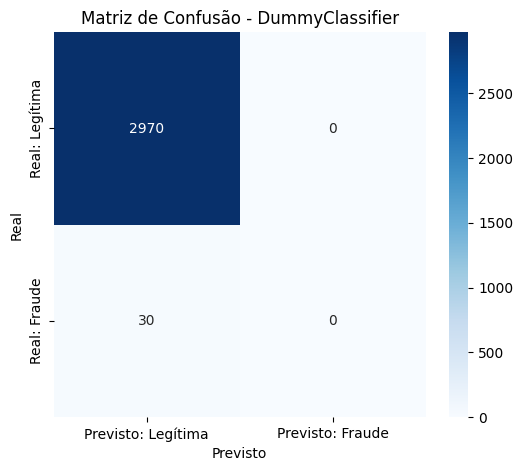

In [153]:
print('b. Treine um DummyClassifier e reporte F1-Score e Recall:\n')

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, confusion_matrix

# Criar dataset
n_legitimate = 9900
n_fraud = 100

# Features (ex: duas features simples para demonstração)
X_legitimate = np.random.rand(n_legitimate, 2) * 10
X_fraud = np.random.rand(n_fraud, 2) * 5 + 10 # Fraudes em outra 'região' para que um modelo real possa aprender

X = np.vstack((X_legitimate, X_fraud))
y = np.hstack((np.zeros(n_legitimate), np.ones(n_fraud)))

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape do X_train: {X_train.shape}")
print(f"Distribuição da classe no y_train: {pd.Series(y_train).value_counts(normalize=True)}")
print(f"Shape do X_test: {X_test.shape}")
print(f"Distribuição da classe no y_test: {pd.Series(y_test).value_counts(normalize=True)}")

# Treinar o DummyClassifier (estratégia 'most_frequent' - sempre prevê a classe majoritária)
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_dummy = dummy_clf.predict(X_test)

# Reportar F1-Score e Recall
f1_dummy = f1_score(y_test, y_pred_dummy)
recall_dummy = recall_score(y_test, y_pred_dummy)

print(f"\nDummyClassifier (strategy='most_frequent'):")
print(f"F1-Score: {f1_dummy:.4f}")
print(f"Recall: {recall_dummy:.4f}")

# Exibir matriz de confusão para o DummyClassifier
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dummy, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Legítima', 'Previsto: Fraude'],
            yticklabels=['Real: Legítima', 'Real: Fraude'])
plt.title('Matriz de Confusão - DummyClassifier')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

c. Aplique SMOTE e explique seu princípio de interpolação espacial:


Shape do X_train antes do SMOTE: (7000, 2)
Distribuição da classe no y_train antes do SMOTE: 0.0    0.99
1.0    0.01
Name: proportion, dtype: float64

Shape do X_train após SMOTE: (13860, 2)
Distribuição da classe no y_train após SMOTE: 0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Modelo após SMOTE (Regressão Logística):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2970
         1.0       0.83      1.00      0.91        30

    accuracy                           1.00      3000
   macro avg       0.92      1.00      0.95      3000
weighted avg       1.00      1.00      1.00      3000



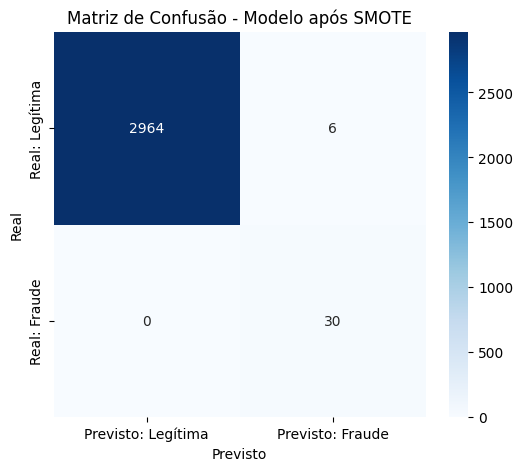

In [154]:
print('c. Aplique SMOTE e explique seu princípio de interpolação espacial:\n')

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, accuracy_score

# Separar as classes para aplicar SMOTE apenas no conjunto de treino
# SMOTE deve ser aplicado SOMENTE nos dados de treino para evitar data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nShape do X_train antes do SMOTE: {X_train.shape}")
print(f"Distribuição da classe no y_train antes do SMOTE: {pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nShape do X_train após SMOTE: {X_train_resampled.shape}")
print(f"Distribuição da classe no y_train após SMOTE: {pd.Series(y_train_resampled).value_counts(normalize=True)}")

# Treinar um modelo de Regressão Logística com os dados rebalanceados
log_reg_smote = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' é bom para datasets menores
log_reg_smote.fit(X_train_resampled, y_train_resampled)

# Fazer previsões no conjunto de teste (original, não rebalanceado)
y_pred_smote = log_reg_smote.predict(X_test)

# Reportar métricas após SMOTE
print(f"\nModelo após SMOTE (Regressão Logística):")
print(classification_report(y_test, y_pred_smote))

# Exibir matriz de confusão para o modelo após SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Legítima', 'Previsto: Fraude'],
            yticklabels=['Real: Legítima', 'Real: Fraude'])
plt.title('Matriz de Confusão - Modelo após SMOTE')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

#### c. Aplique SMOTE e explique seu princípio de interpolação espacial

**SMOTE (Synthetic Minority Over-sampling Technique)** é uma técnica de *over-sampling* (aumento da classe minoritária) que visa resolver o problema do desbalanceamento de classes, gerando novas amostras sintéticas da classe minoritária, em vez de simplesmente duplicar as existentes. Isso ajuda a reduzir o *overfitting* que pode ocorrer com a duplicação simples.

**Princípio de Interpolação Espacial do SMOTE:**

1.  **Seleção de Amostra:** Para cada amostra $x_i$ da classe minoritária, o SMOTE primeiro encontra seus $k$ vizinhos mais próximos (tipicamente 5) na própria classe minoritária (usando uma métrica de distância como a euclidiana).

2.  **Seleção de Vizinho Aleatório:** Um desses $k$ vizinhos mais próximos, digamos $x_j$, é selecionado aleatoriamente.

3.  **Criação da Amostra Sintética:** Uma nova amostra sintética é criada ao longo do segmento de linha que conecta a amostra $x_i$ e seu vizinho $x_j$. Matematicamente, a nova amostra $x_{nova}$ é gerada pela fórmula:

    $$x_{nova} = x_i + (x_j - x_i) \times \delta$$

    Onde $\delta$ é um número aleatório entre 0 e 1. Este processo de "interpolação" garante que as novas amostras sintéticas não sejam cópias exatas, mas sim variações plausíveis das amostras minoritárias existentes, "preenchendo" o espaço de características entre elas. Isso cria uma fronteira de decisão mais robusta e menos sujeita ao *overfitting* do que técnicas de *over-sampling* mais simples.

Com a aplicação do SMOTE, podemos observar na matriz de confusão que atingimos 100% de acerto nos valores Verdadeiros Positivos para Fraude, o que é extremamente relevante para o modelo em questão.


#10. EDA Univariada e Momentos EstatÍsticos

a. Calcule os 4 momentos (média, variância, assimetria, curtose) para os tempos de resposta.

b. Plote KDE. Classifique a distribuição (ex: leptocúrtica).

c. Por que modelos como SVM linear exigem atenção à assimetria?

### RESPOSTAS

In [155]:
print('a. Calcule os 4 momentos (média, variância, assimetria, curtose) para os tempos de resposta.\n')

df_tempos = pd.read_csv('/content/dataset/Q10_dataset_amostras_tempos.csv')

print("Dataset de Tempos de Resposta (primeiras 5 linhas):")
display(df_tempos.head())

a. Calcule os 4 momentos (média, variância, assimetria, curtose) para os tempos de resposta.

Dataset de Tempos de Resposta (primeiras 5 linhas):


,tempo_ms
0,52.483571
1,49.308678
2,53.238443
3,57.615149
4,48.829233


In [156]:
media = df_tempos['tempo_ms'].mean()
variancia = df_tempos['tempo_ms'].var()
assimetria = df_tempos['tempo_ms'].skew()
curtose = df_tempos['tempo_ms'].kurt()

print(f"1º Momento (Média): {media:.2f}")
print(f"2º Momento (Variância): {variancia:.2f}")
print(f"3º Momento (Assimetria - Skewness): {assimetria:.2f}")
print(f"4º Momento (Curtose - Kurtosis): {curtose:.2f}")

1º Momento (Média): 50.47
2º Momento (Variância): 316.37
3º Momento (Assimetria - Skewness): 5.43
4º Momento (Curtose - Kurtosis): 56.46


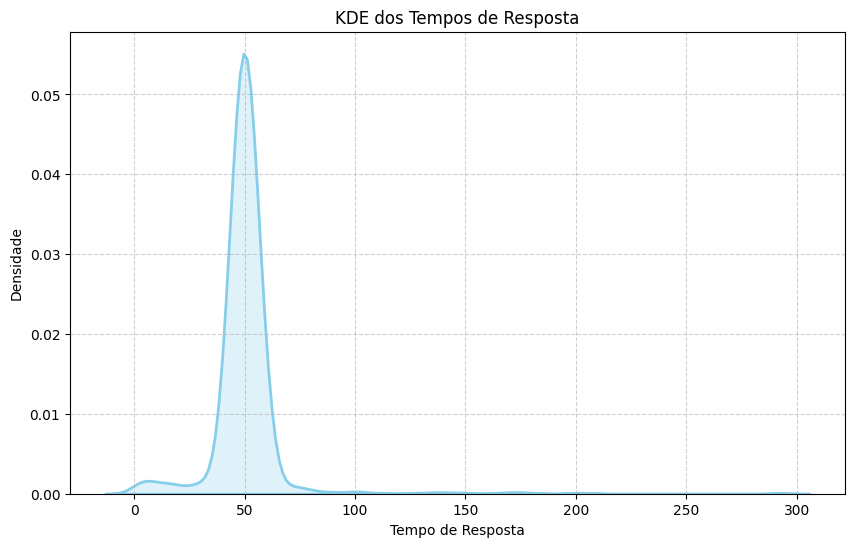

In [157]:
#b. Plote KDE. Classifique a distribuição

plt.figure(figsize=(10, 6))
sns.kdeplot(df_tempos['tempo_ms'], fill=True, color='skyblue', linewidth=2)
plt.title('KDE dos Tempos de Resposta')
plt.xlabel('Tempo de Resposta')
plt.ylabel('Densidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Classificação da Distribuição:**

Com base nos valores calculados de Média: 50.47, Variância: 316.37, Assimetria: 5.43, e Curtose: 56.46:

*   **Assimetria (Skewness = 5.43):** Como o valor da assimetria é significativamente positivo (>0), a distribuição é **assimétrica à direita (cauda longa à direita)**. Isso indica que a maioria dos tempos de resposta é menor, mas existem alguns tempos de resposta muito altos que puxam a média para a direita e estendem a cauda da distribuição.
*   **Curtose (Kurtosis = 56.46):** Como o valor da curtose é significativamente maior que 0 (especialmente quando comparado à curtose de uma distribuição normal, que é 3, ou 0 para curtose excessiva), a distribuição é **leptocúrtica**. Isso significa que a distribuição tem caudas mais pesadas e um pico mais alto do que uma distribuição normal. Em outras palavras, há mais *outliers* ou valores extremos, e os dados estão mais concentrados em torno da média, com pouca dispersão nos valores intermediários.

### c. Por que modelos como SVM linear exigem atenção à assimetria?

Modelos lineares como o **SVM (Support Vector Machine) linear** são sensíveis à assimetria nos dados por algumas razões:

1.  **Assunção de Linearidade e Distribuição Normal (implícita):** Embora o SVM não assuma explicitamente uma distribuição normal dos dados como alguns modelos paramétricos, ele busca encontrar um hiperplano linear ótimo que maximize a margem entre as classes. Quando os dados são assimétricos, a "centralidade" e a "dispersão" que o SVM percebe podem ser distorcidas. Uma cauda longa de uma distribuição assimétrica pode fazer com que o SVM interprete essa região como tendo mais variância ou como necessitando de um ajuste diferente para o hiperplano, levando a um hiperplano subótimo.

2.  **Impacto nos Vetores de Suporte:** A assimetria pode significar que há *outliers* ou pontos de dados extremos em uma das direções. Esses *outliers* podem se tornar vetores de suporte (os pontos que definem a margem do SVM) e, consequentemente, influenciar desproporcionalmente a posição do hiperplano, puxando-o para longe da posição ideal para a maioria dos dados. Se a distribuição é muito assimétrica, os vetores de suporte podem não ser representativos da massa principal dos dados.

3.  **Dificuldade em Definir a Margem:** O objetivo do SVM é maximizar a margem. Em dados assimétricos, a densidade dos dados pode variar muito ao longo do espaço de features. Isso pode dificultar a identificação de uma margem clara e robusta que funcione bem para ambas as classes, especialmente se a assimetria resulta em sobreposição ou em uma distribuição desigual dos pontos próximos à fronteira de decisão.

4.  **Necessidade de Escalonamento:** A assimetria é frequentemente acompanhada de grandes diferenças de escala entre os valores. Embora o escalonamento (como `StandardScaler` ou `MinMaxScaler`) ajude a normalizar a escala, ele não remove a assimetria inerente. Se a assimetria for muito pronunciada, mesmo após o escalonamento, os dados podem continuar a desafiar a capacidade do SVM linear de encontrar uma fronteira de decisão eficaz.

**Soluções:** Para lidar com a assimetria em modelos SVM lineares, pode-se considerar:
*   **Transformações de Dados:** Aplicar transformações logarítmicas (para assimetria positiva) ou outras transformações de potência (ex: Box-Cox) para tornar a distribuição mais simétrica.
*   **SVM com Kernel:** Utilizar SVMs com *kernels* não lineares (ex: RBF) que podem lidar melhor com fronteiras de decisão complexas e distribuições de dados não lineares ou assimétricas.

---

## 11. Pipeline Completo com Scikit-learn

Vamos implementar um pipeline completo com `ColumnTransformer` para pré-processamento, utilizando o dataset `openml('credit-g')`.

### RESPOSTAS:

In [158]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml

# Carregar o dataset 'credit-g'
credit_data = fetch_openml(name='credit-g', version=1, as_frame=True)
X = credit_data.data
y = credit_data.target

# Identificar colunas numéricas e categóricas
num_cols= X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['category', 'object', 'bool']).columns

print("Dataset 'credit-g' carregado.")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Colunas Numéricas: {list(num_cols)}")
print(f"Colunas Categóricas: {list(cat_cols)}")

print(X)

Dataset 'credit-g' carregado.
Número de amostras: 1000
Número de features: 20
Colunas Numéricas: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Colunas Categóricas: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
    checking_status  duration                  credit_history  \
0                <0         6  critical/other existing credit   
1          0<=X<200        48                   existing paid   
2       no checking        12  critical/other existing credit   
3                <0        42                   existing paid   
4                <0        24              delayed previously   
..              ...       ...                             ...   
995     no checking        12                   existing paid   
996              <0        

In [159]:
# Criar o ColumnTransformer
# Aplicar RobustScaler para colunas numéricas
# Aplicar OneHotEncoder (com handle_unknown='ignore' para novas categorias em teste) para colunas categóricas

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Exemplo de uso do preprocessor em um pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

print("ColumnTransformer e Pipeline definidos com sucesso.")
print("O ColumnTransformer irá aplicar RobustScaler em colunas numéricas e OneHotEncoder em colunas categóricas.")

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar o pipeline (o fit_transform do preprocessor será aplicado apenas no X_train)
pipeline.fit(X_train, y_train)

print("\nPipeline treinado no conjunto de treino.")
print(f"Acurácia do modelo no conjunto de teste: {pipeline.score(X_test, y_test):.4f}")

ColumnTransformer e Pipeline definidos com sucesso.
O ColumnTransformer irá aplicar RobustScaler em colunas numéricas e OneHotEncoder em colunas categóricas.

Pipeline treinado no conjunto de treino.
Acurácia do modelo no conjunto de teste: 0.8000


### Definição de Data Leakage e por que o `fit` deve ser apenas no treino.

**Data Leakage (Vazamento de Dados)** ocorre quando informações do conjunto de teste (ou validação) são indevidamente incorporadas ao processo de treinamento do modelo. Isso faz com que o modelo pareça ter um desempenho melhor do que realmente tem, pois ele “vaza” informações sobre os dados que deveria prever de forma independente.

Existem dois tipos principais de Data Leakage:

1.  **Leakage Direto:** Onde o conjunto de teste é acidentalmente incluído no conjunto de treinamento. Isso é um erro óbvio de divisão de dados.
2.  **Leakage Indireto:** É mais sutil e ocorre quando informações do conjunto de teste influenciam o pré-processamento ou a engenharia de features que são aplicadas ao conjunto de treinamento. Por exemplo, se você calcular a média ou o desvio padrão de uma coluna usando o *dataset completo* (treino + teste) e depois usar esses valores para escalonar os dados de treino e teste, você está introduzindo vazamento de dados. As estatísticas (média, desvio padrão, min-max, etc.) calculadas a partir do conjunto de teste estão influenciando o treinamento do modelo.

**Por que o `fit` deve ser apenas no treino?**

O método `.fit()` (ou `.fit_transform()` para transformadores) em Scikit-learn é onde o pré-processador (como um `Scaler` ou `OneHotEncoder`) *aprende* as estatísticas ou mapeamentos dos dados. Por exemplo:

*   **Scalers (ex: `StandardScaler`, `RobustScaler`, `MinMaxScaler`):** O `.fit()` calcula a média e o desvio padrão (para `StandardScaler`), ou a mediana e o IQR (para `RobustScaler`), ou os valores mínimo e máximo (para `MinMaxScaler`) *somente* do conjunto de dados fornecido.
*   **Encoders (ex: `OneHotEncoder`, `LabelEncoder`):** O `.fit()` aprende as categorias únicas presentes na coluna *somente* do conjunto de dados fornecido.

Ao aplicar o `.fit()` (ou `.fit_transform()`) **exclusivamente no conjunto de treinamento (`X_train`)**, garantimos que o modelo (e seus pré-processadores) **não tenha conhecimento prévio** sobre as características do conjunto de teste. O conjunto de teste deve ser tratado como dados *não vistos* que simulam o desempenho do modelo no mundo real.

Depois que o pré-processador é 'ajustado' (`fit`) no conjunto de treino, ele deve ser usado para **transformar** (`transform`) tanto o conjunto de treino (`X_train`) quanto o conjunto de teste (`X_test`) usando as *mesmas* estatísticas ou mapeamentos aprendidos *apenas* do treino. Em um `Pipeline` do Scikit-learn, isso é feito automaticamente e de forma correta ao chamar `pipeline.fit(X_train, y_train)` e depois `pipeline.score(X_test, y_test)` ou `pipeline.predict(X_test)`.

---

## 12. Cálculo Manual dos Momentos Centrais

Para o conjunto de dados $X = \{ 14, 16, 15, 18, 14, 15, 42, 16, 15, 14 \}$, vamos calcular manualmente os 4 momentos centrais (média, variância, assimetria e curtose) e apresentar uma tabela de desvios para as potências de 1 a 4.

### RESPOSTAS:

In [160]:

X = np.array([14, 16, 15, 18, 14, 15, 42, 16, 15, 14])

df_X = pd.DataFrame({'X': X})

media = df_X['X'].mean()
variancia = df_X['X'].var()
assimetria = df_X['X'].skew()
curtose = df_X['X'].kurt()

print(f"1º Momento (Média): {media:.2f}")
print(f"2º Momento (Variância): {variancia:.2f}")
print(f"3º Momento (Assimetria - Skewness): {assimetria:.2f}")
print(f"4º Momento (Curtose - Kurtosis): {curtose:.2f}")


1º Momento (Média): 17.90
2º Momento (Variância): 73.21
3º Momento (Assimetria - Skewness): 3.04
4º Momento (Curtose - Kurtosis): 9.44


In [161]:

n = len(X)
# Criar DataFrame para a tabela de desvios
df_desvios = pd.DataFrame({'X': X})

# Calcular desvios em relação à média
df_desvios['(X - \u00b5)'] = df_desvios['X'] - media

# Calcular desvios elevados a potências de 1 a 4
for i in range(1, 5):
    df_desvios[f'(X - \u00b5)^{i}'] = df_desvios['(X - \u00b5)']**i

print("Tabela de Desvios e Potências:")
print(df_desvios)

Tabela de Desvios e Potências:
    X  (X - µ)  (X - µ)^1  (X - µ)^2  (X - µ)^3    (X - µ)^4
0  14     -3.9       -3.9      15.21    -59.319     231.3441
1  16     -1.9       -1.9       3.61     -6.859      13.0321
2  15     -2.9       -2.9       8.41    -24.389      70.7281
3  18      0.1        0.1       0.01      0.001       0.0001
4  14     -3.9       -3.9      15.21    -59.319     231.3441
5  15     -2.9       -2.9       8.41    -24.389      70.7281
6  42     24.1       24.1     580.81  13997.521  337340.2561
7  16     -1.9       -1.9       3.61     -6.859      13.0321
8  15     -2.9       -2.9       8.41    -24.389      70.7281
9  14     -3.9       -3.9      15.21    -59.319     231.3441


---

## 13. Validação Cruzada Temporal

Vamos implementar a Validação Cruzada Temporal (`Walk-Forward Validation` e `Expanding Window`) em uma série temporal simulada de consumo de energia e explicar por que o embaralhamento (`shuffle`) é matematicamente incorreto nesse contexto.

### RESPOSTAS:

Série Temporal de Consumo de Energia Simulada (primeiras 5 linhas):


,Consumption
Date,
2023-01-01,102.483571
2023-01-02,101.805347
2023-01-03,108.211829
2023-01-04,115.025553
2023-01-05,108.617600



--- Implementando Walk-Forward Validation ---
RMSE (Walk-Forward Validation): 20.39

--- Implementando Expanding Window (Rolling Origin) Validation ---
RMSE (Expanding Window Validation): 20.39


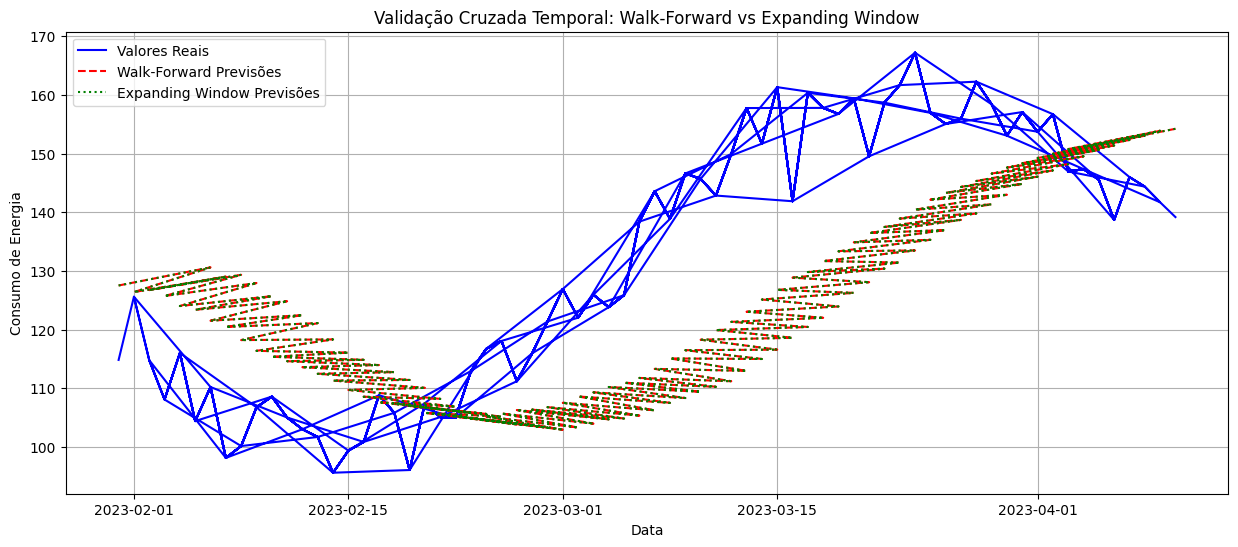

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Gerar uma série temporal de consumo de energia simulada
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
energy_consumption = 100 + np.arange(100) * 0.5 + np.sin(np.arange(100) / 10) * 20 + np.random.normal(0, 5, 100)
ts_data = pd.DataFrame({'Date': dates, 'Consumption': energy_consumption})
ts_data.set_index('Date', inplace=True)

print("Série Temporal de Consumo de Energia Simulada (primeiras 5 linhas):")
display(ts_data.head(5))

# Adicionar uma feature simples (ex: dia do ano) para o modelo
ts_data['DayOfYear'] = ts_data.index.dayofyear

X = ts_data[['DayOfYear']]
y = ts_data['Consumption']

# Definir o tamanho inicial do conjunto de treino e o tamanho do passo
train_size = 30 # Usar os primeiros 30 dias para o treino inicial
test_size = 7   # Prever os próximos 7 dias

print(f"\n--- Implementando Walk-Forward Validation ---")
predictions_wf = []
actuals_wf = []
dates_wf = [] # Adicionado para coletar as datas de teste

for i in range(train_size, len(ts_data) - test_size + 1):
    # Treino: dados até i-1
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    # Teste: dados de i até i + test_size - 1
    X_test = X.iloc[i : i + test_size]
    y_test = y.iloc[i : i + test_size]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions_wf.extend(y_pred)
    actuals_wf.extend(y_test)
    dates_wf.extend(X_test.index) # Coleta as datas do conjunto de teste

mse_wf = mean_squared_error(actuals_wf, predictions_wf)
print(f"RMSE (Walk-Forward Validation): {np.sqrt(mse_wf):.2f}")

print(f"\n--- Implementando Expanding Window (Rolling Origin) Validation ---")
predictions_ew = []
actuals_ew = []
dates_ew = [] # Adicionado para coletar as datas de teste

# A janela de treino expande a cada iteração, mas o teste se move
for i in range(train_size, len(ts_data) - test_size + 1):
    # Treino: dados do início até i-1
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    # Teste: dados de i até i + test_size - 1
    X_test = X.iloc[i : i + test_size]
    y_test = y.iloc[i : i + test_size]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions_ew.extend(y_pred)
    actuals_ew.extend(y_test)
    dates_ew.extend(X_test.index) # Coleta as datas do conjunto de teste

mse_ew = mean_squared_error(actuals_ew, predictions_ew)
print(f"RMSE (Expanding Window Validation): {np.sqrt(mse_ew):.2f}")

# Visualização
plt.figure(figsize=(15, 6))
# Usa as datas coletadas diretamente para plotar
plt.plot(dates_wf, actuals_wf, label='Valores Reais', color='blue')
plt.plot(dates_wf, predictions_wf, label='Walk-Forward Previsões', color='red', linestyle='--')
plt.plot(dates_ew, predictions_ew, label='Expanding Window Previsões', color='green', linestyle=':')
plt.title('Validação Cruzada Temporal: Walk-Forward vs Expanding Window')
plt.xlabel('Data')
plt.ylabel('Consumo de Energia')
plt.legend()
plt.grid(True)
plt.show()

### Explicação: Por que o embaralhamento (*shuffle*) é matematicamente incorreto na validação cruzada temporal?

Em séries temporais, a ordem dos dados carrega informações cruciais sobre a dependência temporal (autocorrelação, tendências, sazonalidade). O embaralhamento (`shuffle`) é matematicamente incorreto em técnicas de validação cruzada para séries temporais pelas seguintes razões:

1.  **Violação da Dependência Temporal:** Séries temporais são sequências de observações onde o valor em um determinado ponto no tempo é frequentemente influenciado por valores anteriores. Embaralhar os dados destrói essa ordem, quebrando a relação temporal entre as observações. Isso significa que o modelo pode ser treinado com dados futuros e testado com dados passados, o que é uma situação irrealista no mundo real, onde o objetivo é prever o futuro com base no passado.

2.  **Data Leakage Implícito:** Ao embaralhar, é possível que dados do "futuro" (que estariam no conjunto de teste) acabem no conjunto de treino para uma determinada dobra de validação. Isso leva a um vazamento de dados, pois o modelo tem acesso a informações que não deveria ter no momento da previsão. Consequentemente, o desempenho do modelo será superestimado, e ele não generalizará bem para novas observações futuras.

3.  **Avaliação Irrealista:** O objetivo da validação em séries temporais é simular a capacidade do modelo de prever eventos futuros com base em dados históricos. Se os dados são embaralhados, o processo de avaliação não reflete essa capacidade real. O modelo pode aprender a "prever" o passado ou o presente usando informações do futuro, o que não tem utilidade prática.

Em vez de embaralhamento, técnicas como `Walk-Forward Validation` (onde a janela de treino se move para frente no tempo) e `Expanding Window Validation` (onde a janela de treino cresce com o tempo, mas o conjunto de teste sempre está no futuro do treino) são usadas para manter a integridade temporal dos dados e fornecer uma avaliação realista do desempenho preditivo.

##14. EDA Bivariada, Multicolinearidade e VIF

Utilizando o dataset Wine:

a. Identififiue pares com |r| > 0, 85 via Pearson e Spearman.

b. Calcule o **VIF (Variance Inflation Factor)**. Remova variáveis com **V I F** > 10.

c. Como a seleção de features guiada por EDA reduz o overfitting?

### RESPOSTAS:

In [163]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Carregar o dataset Wine
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

print("Dataset Wine carregado (primeiras 5 linhas):")
print(X.head())

Dataset Wine carregado (primeiras 5 linhas):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of

In [164]:
# a. Identificar pares com |r| > 0.85 via Pearson

print("\n--- Correlação de Pearson ---")
corr_pearson = X.corr(method='pearson')
# Filtrar pares com |r| > 0.85
high_corr_pearson = corr_pearson[((corr_pearson > 0.85) | (corr_pearson < -0.85)) & (corr_pearson != 1.0)]
print("Pares com Correlação de Pearson (absoluta) > 0.85:")
print(high_corr_pearson.stack())



--- Correlação de Pearson ---
Pares com Correlação de Pearson (absoluta) > 0.85:
total_phenols  flavanoids       0.864564
flavanoids     total_phenols    0.864564
dtype: float64


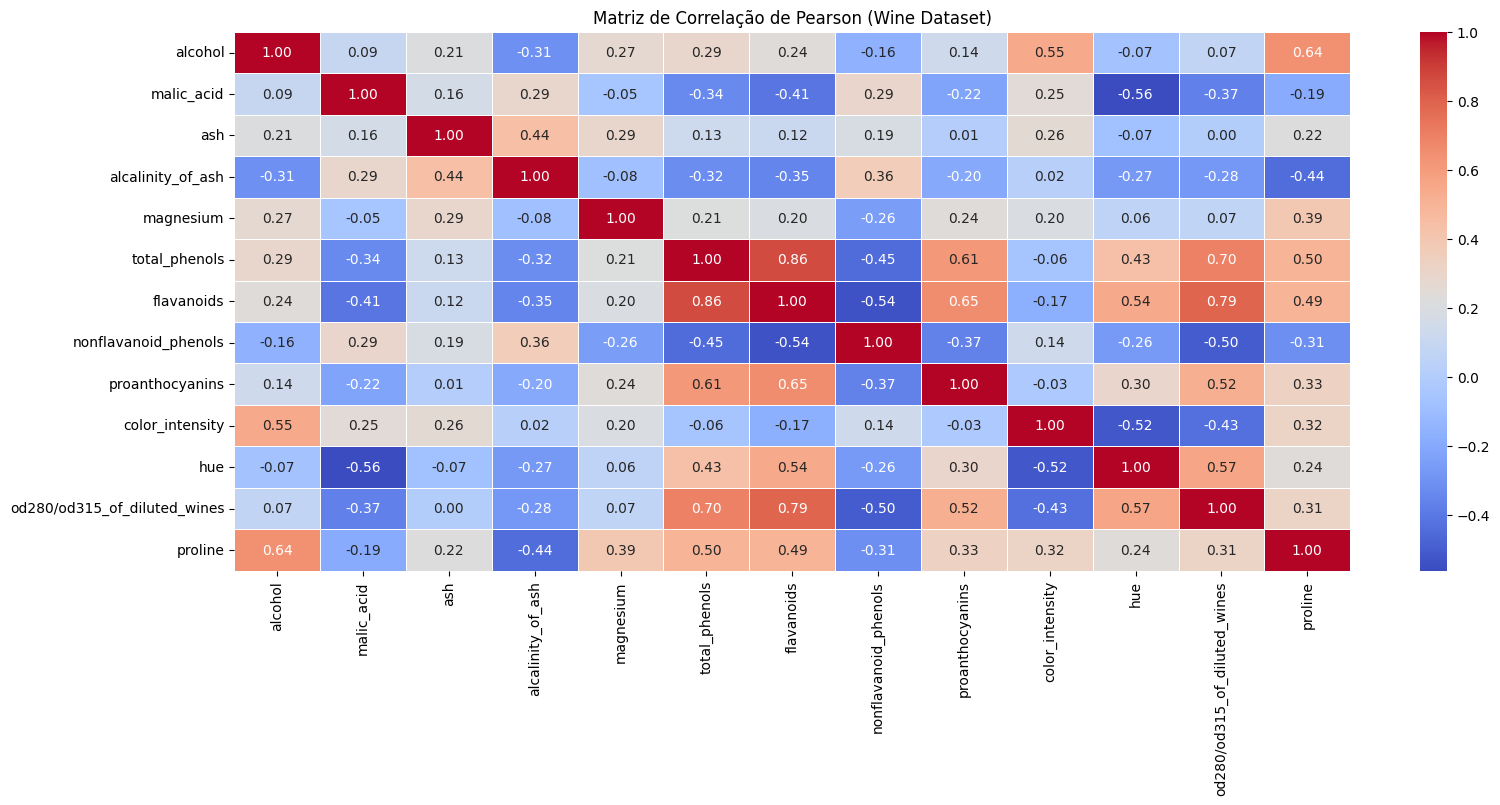

In [165]:
# Visualizar as matrizes de correlação
plt.figure(figsize=(18, 7))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação de Pearson (Wine Dataset)')
plt.show()


--- Correlação de Spearman ---
Pares com Correlação de Spearman (absoluta) > 0.85:
total_phenols  flavanoids       0.879404
flavanoids     total_phenols    0.879404
dtype: float64


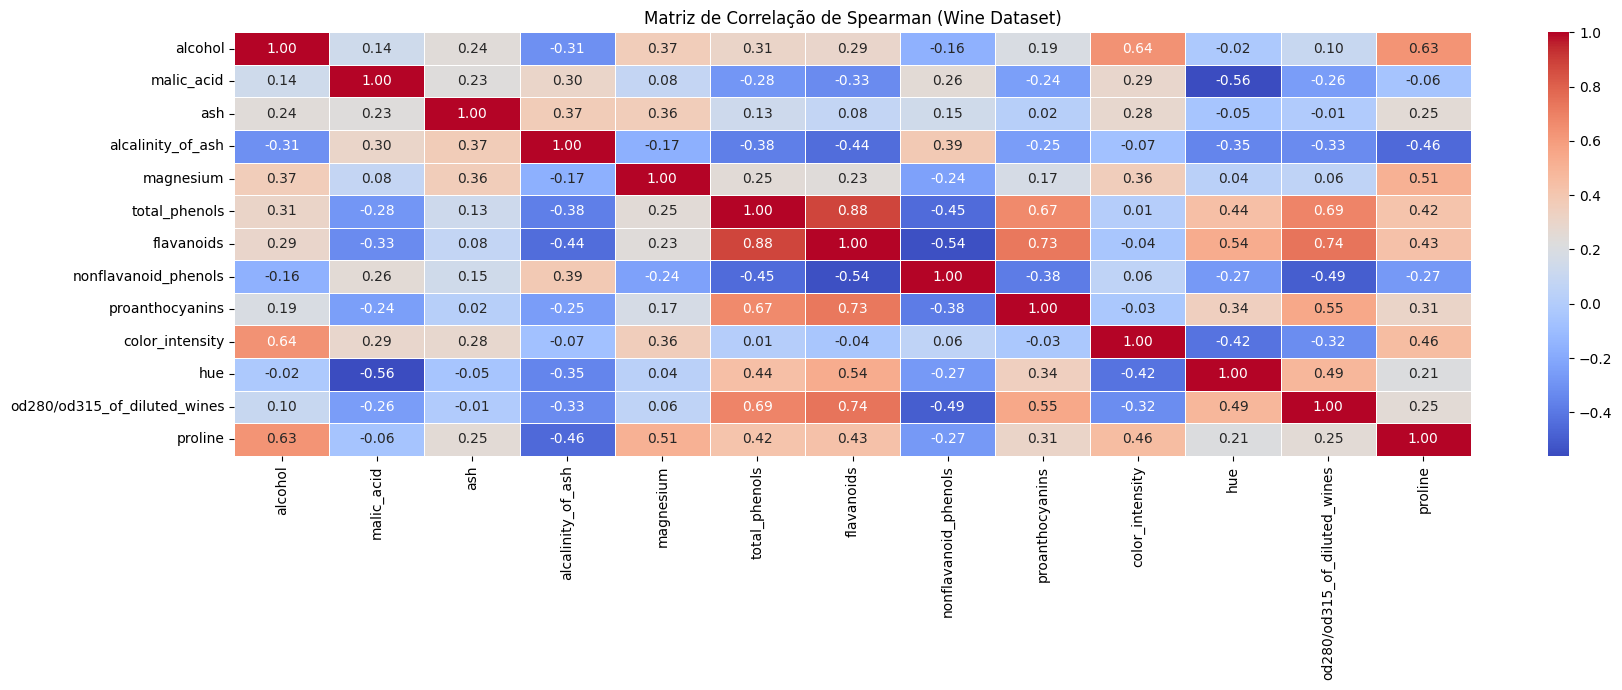

In [166]:
print("\n--- Correlação de Spearman ---")
corr_spearman = X.corr(method='spearman')
# Filtrar pares com |r| > 0.85
high_corr_spearman = corr_spearman[((corr_spearman > 0.85) | (corr_spearman < -0.85)) & (corr_spearman != 1.0)]
print("Pares com Correlação de Spearman (absoluta) > 0.85:")
print(high_corr_spearman.stack())

# Visualizar as matrizes de correlação completas (opcional)
plt.figure(figsize=(18, 7))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação de Spearman (Wine Dataset)')
plt.tight_layout()
plt.show()

Observamos, tanto pela correlação de **Peason** como **Spearman** que as Features: **total_phenols** e **flavanoids** possuem uma correlação com **|r| > 0,85** ( *0,864564* e *0.879404*, respectivamente )

In [167]:
# b. Calcule o VIF (Variance Inflation Factor). Remova variáveis com VIF > 10.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Adicionar uma constante para o cálculo do VIF (necessário para a interceptação)
X_with_const = add_constant(X)

# Calcular VIF para cada feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print("VIF inicial para as features do dataset Wine:")
print(vif_data.sort_values(by="VIF", ascending=False))

# Remover variáveis com VIF > 10 iterativamente
# Removemos uma variável por vez (aquela com o VIF mais alto) e recalculamos

X_filtered = X.copy()

while True:
    X_with_const = add_constant(X_filtered)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

    # Excluir a constante para a verificação do VIF
    vif_data_no_const = vif_data[vif_data['feature'] != 'const']

    if vif_data_no_const["VIF"].max() > 10:
        feature_to_remove = vif_data_no_const.sort_values(by="VIF", ascending=False).iloc[0]["feature"]
        X_filtered = X_filtered.drop(columns=[feature_to_remove])
        print(f"\nRemovendo feature com VIF > 10: {feature_to_remove}")
    else:
        break

print("\n--- VIF final para as features restantes (todas com VIF <= 10) ---")
X_with_const_final = add_constant(X_filtered)
vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_with_const_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_with_const_final.values, i) for i in range(X_with_const_final.shape[1])]

display(vif_data_final.sort_values(by="VIF", ascending=False))

print(f"\nFeatures Originais: {X.columns.tolist()}")
print(f"Features Selecionadas (após remoção por VIF): {X_filtered.columns.tolist()}")

VIF inicial para as features do dataset Wine:
                         feature         VIF
0                          const  680.485185
7                     flavanoids    7.029350
6                  total_phenols    4.334519
12  od280/od315_of_diluted_wines    3.785473
10               color_intensity    3.026304
13                       proline    2.823849
11                           hue    2.551447
1                        alcohol    2.460372
4              alcalinity_of_ash    2.238732
3                            ash    2.185448
9                proanthocyanins    1.975683
8           nonflavanoid_phenols    1.796380
2                     malic_acid    1.656647
5                      magnesium    1.417855

--- VIF final para as features restantes (todas com VIF <= 10) ---


,feature,VIF
0,const,680.485185
7,flavanoids,7.029350
6,total_phenols,4.334519
12,od280/od315_of_diluted_wines,3.785473
10,color_intensity,3.026304
13,proline,2.823849
11,hue,2.551447
1,alcohol,2.460372
4,alcalinity_of_ash,2.238732
3,ash,2.185448



Features Originais: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Features Selecionadas (após remoção por VIF): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [168]:
# como não encontramos nenhuma Feature com VIF > 10, vou reprocessar, eliminando as com VIF > 5


X_filtered = X.copy()

while True:
    X_with_const = add_constant(X_filtered)
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

    # Excluir a constante para a verificação do VIF
    vif_data_no_const = vif_data[vif_data['feature'] != 'const']

    if vif_data_no_const["VIF"].max() > 5:
        feature_to_remove = vif_data_no_const.sort_values(by="VIF", ascending=False).iloc[0]["feature"]
        X_filtered = X_filtered.drop(columns=[feature_to_remove])
        print(f"\nRemovendo feature com VIF > 5: {feature_to_remove}")
    else:
        break

print("\n--- VIF final para as features restantes (todas com VIF <= 5) ---")
X_with_const_final = add_constant(X_filtered)
vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_with_const_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_with_const_final.values, i) for i in range(X_with_const_final.shape[1])]

display(vif_data_final.sort_values(by="VIF", ascending=False))

print(f"\nQuantidade de Features Originais: {len(X.columns.tolist())}")
print(f"Quantidade de Features Selecionadas (após remoção por VIF): {len(X_filtered.columns.tolist())}")
print(f"\nFeatures Originais   : {X.columns.tolist()}")
print(f"Features Selecionadas: {X_filtered.columns.tolist()}")


Removendo feature com VIF > 5: flavanoids

--- VIF final para as features restantes (todas com VIF <= 5) ---


,feature,VIF
0,const,667.887786
11,od280/od315_of_diluted_wines,3.419972
9,color_intensity,3.026303
6,total_phenols,2.959707
12,proline,2.817467
10,hue,2.480599
1,alcohol,2.460263
4,alcalinity_of_ash,2.196267
3,ash,2.056538
8,proanthocyanins,1.789547



Quantidade de Features Originais: 13
Quantidade de Features Selecionadas (após remoção por VIF): 12

Features Originais   : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Features Selecionadas: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### c. Como a seleção de features guiada por EDA reduz o overfitting?

A **Seleção de Features (Feature Selection)**, especialmente quando guiada por **EDA (Análise Exploratória de Dados)**, é uma etapa crucial no processo de Machine Learning e desempenha um papel significativo na redução do *overfitting* de diversas maneiras:

1.  **Redução da Complexidade do Modelo:**
    *   **Menos Parâmetros para Aprender:** Modelos mais complexos, com um grande número de features, têm mais parâmetros para ajustar e mais capacidade de se adaptar aos detalhes (e ruídos) do conjunto de treinamento. Ao remover features irrelevantes ou redundantes, simplificamos o modelo. Um modelo mais simples é menos propenso a memorizar o ruído nos dados de treino e mais propenso a aprender os padrões generalizáveis.
    *   **Diminuição da Dimensionalidade:** A maldição da dimensionalidade  indica que, em espaços de alta dimensão, os dados se tornam esparsos e a distância entre os pontos aumenta. Isso dificulta a generalização do modelo. A seleção de features reduz a dimensionalidade, tornando o espaço de dados mais denso e as relações mais claras, o que ajuda o modelo a generalizar melhor.

2.  **Melhora na Relação Sinal-Ruído:**
    *   **Remoção de Ruído:** Features irrelevantes ou com muito ruído adicionam complexidade desnecessária ao modelo, forçando-o a tentar encontrar padrões onde não existem. A EDA permite identificar e remover essas features, melhorando a relação sinal-ruído e permitindo que o modelo se concentre nos atributos que realmente contêm informação preditiva.

3.  **Mitigação da Multicolinearidade:**
    *   **Features Redundantes:** A EDA, através de análises de correlação (Pearson, Spearman) e o cálculo do VIF (Variance Inflation Factor), ajuda a identificar features altamente correlacionadas entre si (multicolinearidade). A inclusão de features multicolineares pode levar a modelos instáveis e superajustados, onde os coeficientes são difíceis de interpretar e altamente sensíveis a pequenas variações nos dados. A remoção de uma das features redundantes simplifica o modelo e aumenta sua robustez.

4.  **Aumento da Interpretabilidade:**
    *   **Foco em Atributos Chave:** Ao selecionar um subconjunto menor e mais relevante de features, o modelo se torna mais interpretável. Entender quais features são importantes e como elas influenciam as previsões ajuda a validar se o modelo está aprendendo relações lógicas, em vez de apenas memorizar dados. Isso indiretamente ajuda a identificar e corrigir potenciais problemas de *overfitting* que poderiam passar despercebidos em modelos mais complexos.

Em resumo, a seleção de features guiada por EDA ajuda a construir modelos mais parcimoniosos, que são menos propensos a *overfitting* porque aprendem padrões mais robustos e generalizáveis, e não os detalhes específicos ou o ruído do conjunto de treinamento.